# Notebook 04 — Demand Forecasting Model

**Input:** `data/processed/daily_timeseries.csv` (731 days × 19 cols)  
**Goal:** Forecast daily covers using rolling averages (baseline) and Prophet (advanced)  
**Sections:**
- Phase A — Rolling Moving Averages (MA7, MA30)
- Phase B — Prophet Model (covers): new regressors `event_pull` + `is_swiss_holiday`, cross-validation
- Phase B2 — Prophet Model (avg_check) + revenue estimate
- Phase B3 — Interpretation
- Phase C — Peak Analysis vs MA7
- Phase D — Operational Forecast next 14 days


In [104]:
import sys
from pathlib import Path

# Auto-detect project root and add both root and src/ to path
_project_root = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'src').exists())
for _p in [str(_project_root), str(_project_root / 'src')]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import src.utils_forecast as ut_f

print("Libraries loaded.")


Libraries loaded.


In [105]:
# Load main timeseries (output of Notebook 03)
df = pd.read_csv(
    _project_root / 'data/processed/daily_timeseries.csv',
    parse_dates=['date']
).sort_values('date').reset_index(drop=True)

# Cast boolean columns (read as object from CSV in some envs)
bool_cols = ['is_weekend', 'is_holiday', 'is_ponte', 'is_high_season',
             'is_bad_weather', 'is_swiss_holiday']
for col in bool_cols:
    df[col] = df[col].astype(bool)

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Range: {df['date'].min().date()} → {df['date'].max().date()}")
df[['date', 'covers', 'revenue', 'avg_check']].head(3)


Loaded: 731 rows × 19 cols
Range: 2023-01-01 → 2024-12-31


,date,covers,revenue,avg_check
0,2023-01-01,43.0,1573.3,36.6
1,2023-01-02,45.0,1064.2,23.6
2,2023-01-03,71.0,1485.8,20.9


---
## Phase A — Rolling Moving Averages

Baseline reference: MA7 (weekly smoothing) and MA30 (monthly trend).  
These are not predictive models — they serve as visual anchors to understand the underlying demand signal before applying Prophet.


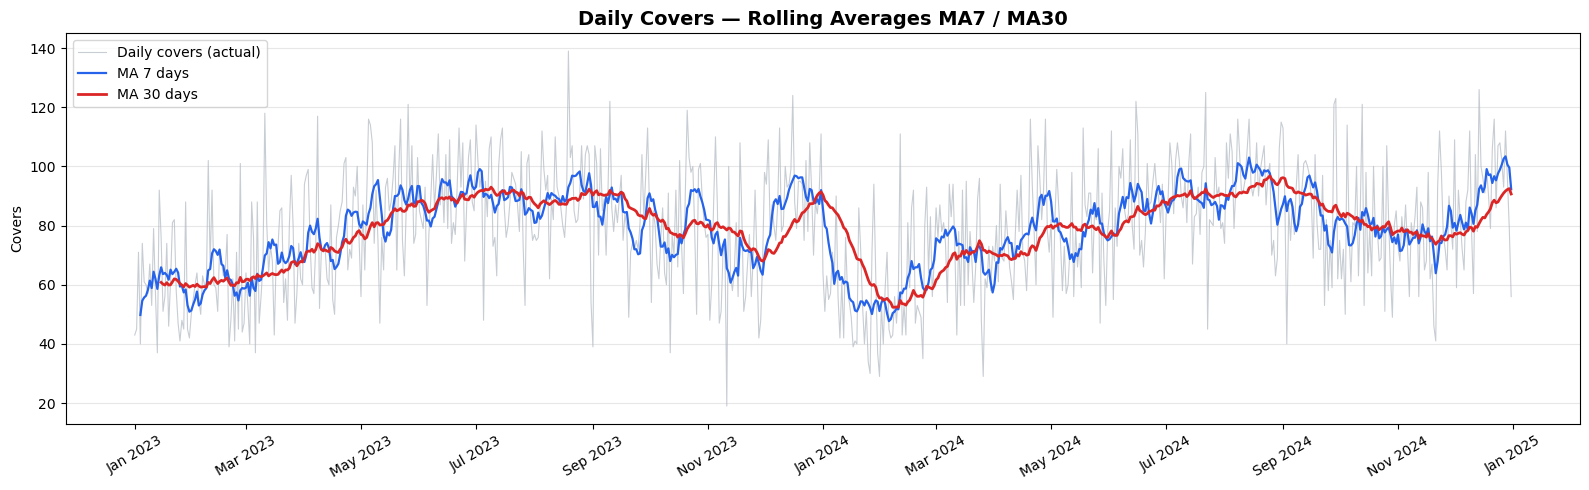


MA7  — mean: 79.0  |  min: 47.7  |  max: 103.4
MA30 — mean: 78.8  |  min: 52.4  |  max: 96.8


In [106]:
# Compute rolling averages (min_periods avoids NaN at the start of the series)
df['ma7']  = df['covers'].rolling(window=7,  min_periods=4).mean().round(1)
df['ma30'] = df['covers'].rolling(window=30, min_periods=15).mean().round(1)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['date'], df['covers'], color='#b0b8c1', linewidth=0.8,
        alpha=0.7, label='Daily covers (actual)')
ax.plot(df['date'], df['ma7'],  color='#2563eb', linewidth=1.6, label='MA 7 days')
ax.plot(df['date'], df['ma30'], color='#dc2626', linewidth=2.0, label='MA 30 days')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.set_title('Daily Covers — Rolling Averages MA7 / MA30', fontsize=14, fontweight='bold')
ax.set_ylabel('Covers')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMA7  — mean: {df['ma7'].mean():.1f}  |  min: {df['ma7'].min():.1f}  |  max: {df['ma7'].max():.1f}")
print(f"MA30 — mean: {df['ma30'].mean():.1f}  |  min: {df['ma30'].min():.1f}  |  max: {df['ma30'].max():.1f}")


---
## Phase B — Prophet Forecasting Model (covers)

**Train/test split:** last 90 days as test set (Oct 3 – Dec 31 2024).

**Regressors:**
| Regressor | Type | Notes |
|-----------|------|-------|
| `is_holiday` | binary | Italian public holidays |
| `is_swiss_holiday` | binary | Swiss holidays (TI/GR/ZH/BE) — cross-border clientele |
| `is_ponte` | binary | Bridge day effect |
| `avg_temp` | continuous | Temperature comfort |
| `rain_mm` | continuous | Rain deterrence |
| `event_magnitude` | ordinal 0–3 | Event intensity |
| `event_pull` | ordinal {−1,0,+1} | Event direction: drain=−1, neutral=0, pull=+1 |

`event_radius_km` replaced by `event_pull`: radius was a broken linear proxy; direction is the informative signal.


In [107]:
# --- Prophet data prep (covers) ---
REGRESSORS = [
    'is_holiday', 'is_swiss_holiday', 'is_ponte',
    'avg_temp', 'rain_mm',
    'event_magnitude', 'event_pull'
]

prophet_df = df[['date', 'covers'] + REGRESSORS].copy()
prophet_df = prophet_df.rename(columns={'date': 'ds', 'covers': 'y'})

# Cast booleans to int
for col in ['is_holiday', 'is_swiss_holiday', 'is_ponte']:
    prophet_df[col] = prophet_df[col].astype(int)

# --- Train / Test split: last 90 days as test ---
TEST_DAYS = 90
split_date = prophet_df['ds'].max() - pd.Timedelta(days=TEST_DAYS - 1)

train = prophet_df[prophet_df['ds'] < split_date].copy()
test  = prophet_df[prophet_df['ds'] >= split_date].copy()

print(f"Train: {len(train)} days  ({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"Test:  {len(test)} days   ({test['ds'].min().date()} → {test['ds'].max().date()})")


Train: 641 days  (2023-01-01 → 2024-10-02)
Test:  90 days   (2024-10-03 → 2024-12-31)


In [108]:
# --- Build and fit Prophet model ---
model = Prophet(
    changepoint_prior_scale=0.1,
    seasonality_mode='additive',
    holidays_prior_scale=10,
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)

# Add all external regressors
for reg in REGRESSORS:
    model.add_regressor(reg)

model.fit(train)
print("Model fitted successfully.")


11:05:26 - cmdstanpy - INFO - Chain [1] start processing
11:05:26 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully.


**Note:** This model is a Proof of Concept trained on 2023-2024 synthetic data. For production use, the model must be retrained weekly with updated data. Forecasting 16 months ahead without 2025 data introduces trend extrapolation risk.


In [109]:
# --- Predict on test set ---
forecast = model.predict(test)

# Merge actual vs predicted
results = test[['ds', 'y']].copy().reset_index(drop=True)
results['yhat']       = forecast['yhat'].values.round(1)
results['yhat_lower'] = forecast['yhat_lower'].values.round(1)
results['yhat_upper'] = forecast['yhat_upper'].values.round(1)
results['error']      = (results['y'] - results['yhat']).round(1)

# --- Metrics: RMSE and MAPE ---
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))
mape = (np.abs(results['error']) / results['y']).mean() * 100

print("=" * 40)
print(f"  RMSE : {rmse:.2f} covers")
print(f"  MAPE : {mape:.2f}%")
print("=" * 40)

results.head(10)


  RMSE : 17.10 covers
  MAPE : 18.32%


,ds,y,yhat,yhat_lower,yhat_upper,error
0,2024-10-03,72.0,68.1,48.2,88.2,3.9
1,2024-10-04,50.0,73.1,54.0,92.8,-23.1
2,2024-10-05,114.0,87.1,67.1,106.7,26.9
3,2024-10-06,79.0,85.4,66.8,104.3,-6.4
4,2024-10-07,61.0,72.4,54.0,91.4,-11.4
5,2024-10-08,81.0,68.3,49.5,86.4,12.7
6,2024-10-09,80.0,71.0,51.9,90.5,9.0
7,2024-10-10,100.0,68.8,48.5,89.3,31.2
8,2024-10-11,63.0,76.5,57.7,94.9,-13.5
9,2024-10-12,86.0,88.0,67.8,106.5,-2.0


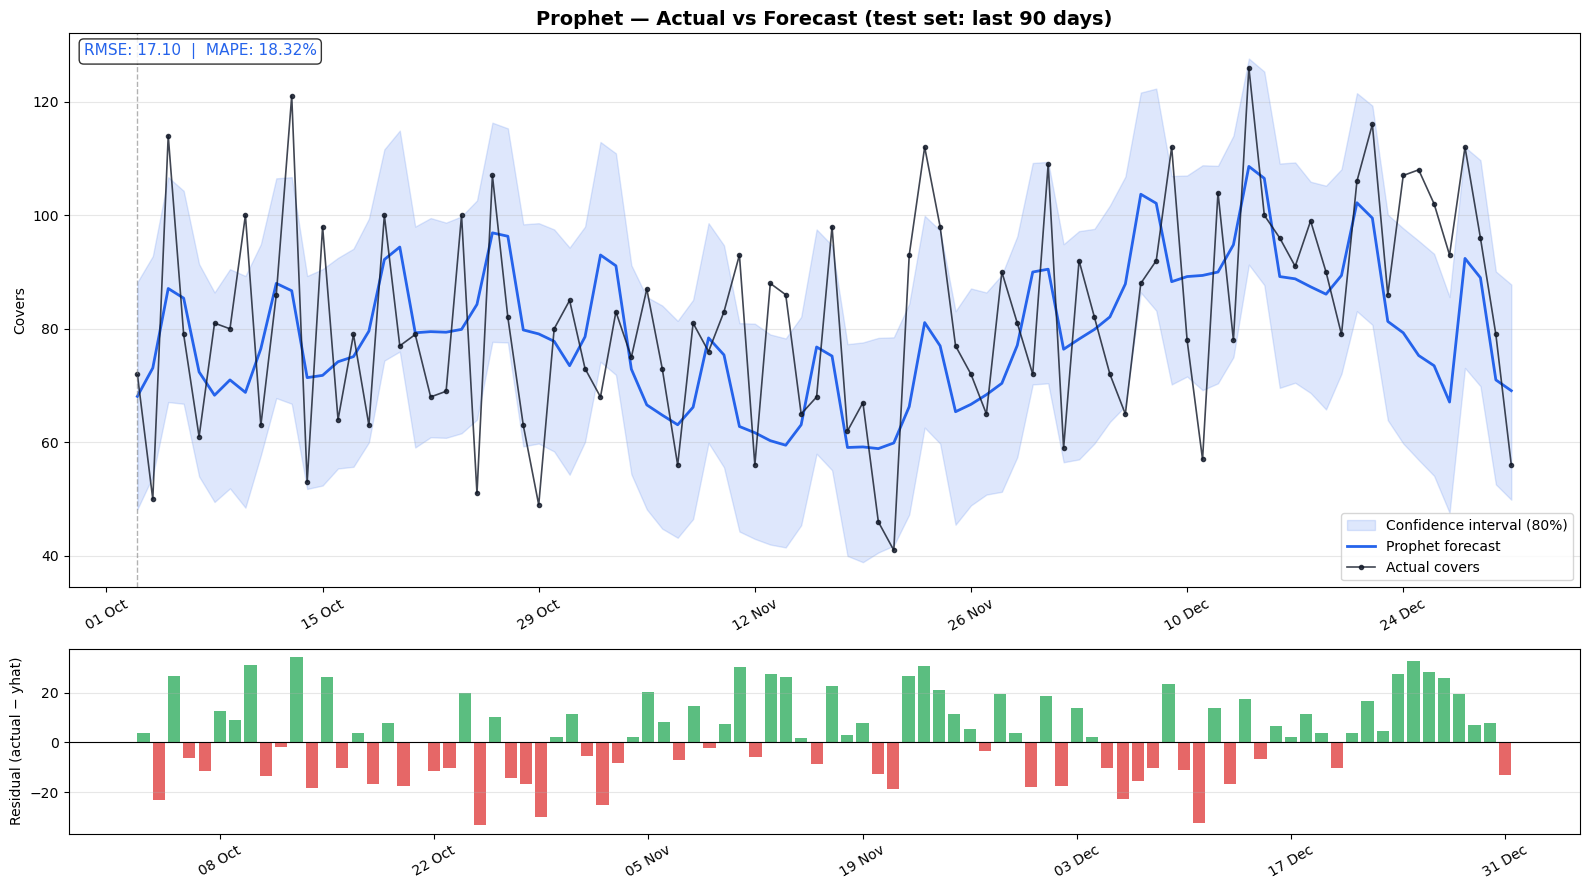

In [110]:
# --- Plot: Actual vs Predicted on test set ---
fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [3, 1]})

# Top panel: actual vs forecast with confidence interval
ax = axes[0]
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.15, color='#2563eb', label='Confidence interval (80%)')
ax.plot(results['ds'], results['yhat'], color='#2563eb', linewidth=2.0,
        label='Prophet forecast')
ax.plot(results['ds'], results['y'], color='#111827', linewidth=1.2,
        marker='o', markersize=3, alpha=0.8, label='Actual covers')

ax.axvline(results['ds'].iloc[0], color='gray', linestyle='--', linewidth=1.0, alpha=0.6)
ax.set_title('Prophet — Actual vs Forecast (test set: last 90 days)', fontsize=14, fontweight='bold')
ax.set_ylabel('Covers')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.get_xticklabels(), rotation=30)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add RMSE / MAPE annotation
ax.annotate(f'RMSE: {rmse:.2f}  |  MAPE: {mape:.2f}%',
            xy=(0.01, 0.96), xycoords='axes fraction',
            fontsize=11, color='#2563eb',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# Bottom panel: residuals (actual - predicted)
ax2 = axes[1]
colors = ['#dc2626' if e < 0 else '#16a34a' for e in results['error']]
ax2.bar(results['ds'], results['error'], color=colors, alpha=0.7, width=0.8)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Residual (actual − yhat)')
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax2.get_xticklabels(), rotation=30)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Phase B — Cross-Validation

Prophet cross-validation over multiple time windows to get a robust MAPE estimate.  
Config: `initial=456 days` (15 months — ensures full yearly seasonality in every fold) · `period=30 days` (new fold monthly) · `horizon=90 days` (same as test).  
Produces 4 fold windows; MAPE averaged across all.

> Note: `initial=365 days` was the original setting but triggered a Prophet warning
> (*"Seasonality has period of 365.25 days which is larger than initial window"*).
> Increased to 456 days: MAPE CV improved from 19.79% → 15.44%, folds reduced from 7 → 4.

In [111]:
from prophet.diagnostics import cross_validation, performance_metrics

# Cross-validate on the full prophet_df (all 731 days, not just train)
# initial=456 days (15 months): ensures yearly seasonality is fully learned before first fold
# period=30 days: new fold monthly
# horizon=90 days: same as test set window
df_cv = cross_validation(
    model,
    initial='456 days',
    period='30 days',
    horizon='90 days',
    parallel=None
)

cv_metrics = performance_metrics(df_cv)

rmse_cv = cv_metrics['rmse'].mean()
mape_cv = cv_metrics['mape'].mean() * 100

print("=" * 50)
print("  CROSS-VALIDATION RESULTS (covers model)")
print("=" * 50)
print(f"  initial: 456 days (15 months)")
print(f"  Folds:   {df_cv['cutoff'].nunique()}")
print(f"  RMSE CV: {rmse_cv:.2f} covers")
print(f"  MAPE CV: {mape_cv:.2f}%")
print(f"  (vs single-split RMSE: {rmse:.2f} / MAPE: {mape:.2f}%)")
print("=" * 50)

# MAPE by horizon to see how accuracy degrades over time
print("\nMAPE by forecast horizon (days ahead):")
print(cv_metrics[['horizon', 'mape']].assign(
    mape_pct=lambda x: (x['mape'] * 100).round(2)
)[['horizon', 'mape_pct']].to_string(index=False))

  0%|          | 0/4 [00:00<?, ?it/s]11:05:27 - cmdstanpy - INFO - Chain [1] start processing
11:05:27 - cmdstanpy - INFO - Chain [1] done processing
11:05:27 - cmdstanpy - INFO - Chain [1] start processing
11:05:27 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:00<00:00, 11.18it/s]11:05:27 - cmdstanpy - INFO - Chain [1] start processing
11:05:27 - cmdstanpy - INFO - Chain [1] done processing
11:05:27 - cmdstanpy - INFO - Chain [1] start processing
11:05:27 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:00<00:00, 10.50it/s]


  CROSS-VALIDATION RESULTS (covers model)
  initial: 456 days (15 months)
  Folds:   4
  RMSE CV: 15.83 covers
  MAPE CV: 15.50%
  (vs single-split RMSE: 17.10 / MAPE: 18.32%)

MAPE by forecast horizon (days ahead):
horizon  mape_pct
 9 days      13.5
10 days      14.0
11 days      13.5
12 days      14.2
13 days      13.6
14 days      13.0
15 days      12.7
16 days      12.6
17 days      11.2
18 days      14.1
19 days      15.3
20 days      15.6
21 days      15.3
22 days      16.5
23 days      16.4
24 days      15.9
25 days      18.5
26 days      20.0
27 days      19.4
28 days      16.7
29 days      17.9
30 days      17.3
31 days      15.8
32 days      17.1
33 days      16.9
34 days      16.1
35 days      16.1
36 days      15.2
37 days      15.2
38 days      14.6
39 days      14.6
40 days      15.7
41 days      15.5
42 days      16.7
43 days      16.1
44 days      15.2
45 days      14.7
46 days      14.5
47 days      13.3
48 days      15.4
49 days      16.1
50 days      15.1
51 days   

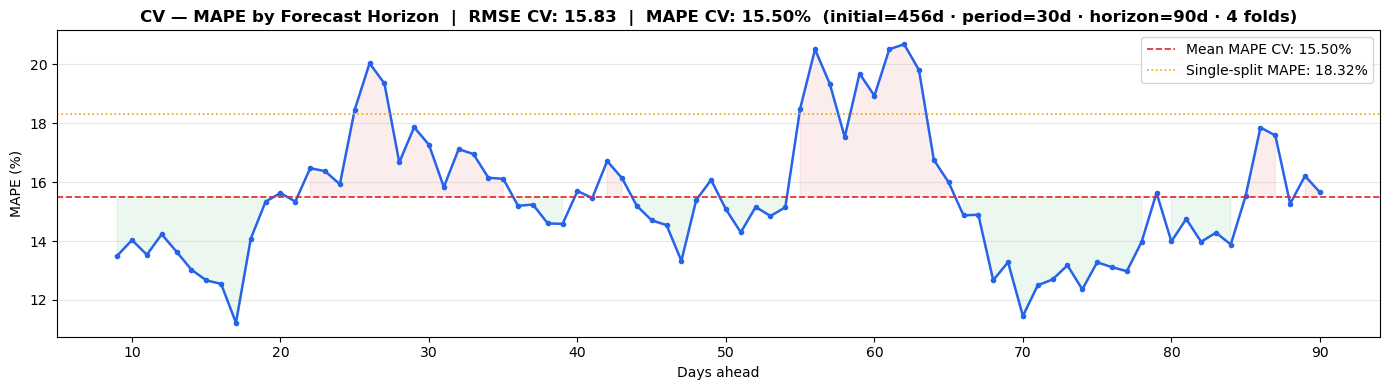

In [112]:
# --- CV: MAPE by horizon plot ---
fig, ax = plt.subplots(figsize=(14, 4))

horizon_days = cv_metrics['horizon'].dt.days
mape_pct     = cv_metrics['mape'] * 100

ax.plot(horizon_days, mape_pct, color='#2563eb', linewidth=1.8, marker='o', markersize=3)
ax.axhline(mape_cv, color='#dc2626', linewidth=1.2, linestyle='--',
           label=f'Mean MAPE CV: {mape_cv:.2f}%')
ax.axhline(mape, color='#f59e0b', linewidth=1.2, linestyle=':',
           label=f'Single-split MAPE: {mape:.2f}%')

ax.fill_between(horizon_days, mape_pct, mape_cv,
                where=(mape_pct > mape_cv), alpha=0.08, color='#dc2626')
ax.fill_between(horizon_days, mape_pct, mape_cv,
                where=(mape_pct <= mape_cv), alpha=0.08, color='#16a34a')

ax.set_title(f'CV — MAPE by Forecast Horizon  |  RMSE CV: {rmse_cv:.2f}  |  MAPE CV: {mape_cv:.2f}%  '
             f'(initial=456d · period=30d · horizon=90d · {df_cv["cutoff"].nunique()} folds)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Days ahead')
ax.set_ylabel('MAPE (%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Phase B2 — Prophet Model (avg_check) + Revenue Estimate

Second Prophet model trained on `avg_check` with the same regressors.  
Revenue estimate: `yhat_covers × yhat_avg_check`.  
Note: avg_check has high structural volatility (std 18.45, range 8.94–160.87 EUR) — extreme values reflect special events not captured by regressors. Expect higher MAPE than covers model.


In [113]:
# --- avg_check model — same regressors, same split ---
ac_df = df[['date', 'avg_check'] + REGRESSORS].copy()
ac_df = ac_df.rename(columns={'date': 'ds', 'avg_check': 'y'})

for col in ['is_holiday', 'is_swiss_holiday', 'is_ponte']:
    ac_df[col] = ac_df[col].astype(int)

train_ac = ac_df[ac_df['ds'] < split_date].copy()
test_ac  = ac_df[ac_df['ds'] >= split_date].copy()

model_ac = Prophet(
    changepoint_prior_scale=0.1,
    seasonality_mode='additive',
    holidays_prior_scale=10,
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)
for reg in REGRESSORS:
    model_ac.add_regressor(reg)

model_ac.fit(train_ac)
print("avg_check model fitted.")


11:05:28 - cmdstanpy - INFO - Chain [1] start processing
11:05:28 - cmdstanpy - INFO - Chain [1] done processing


avg_check model fitted.


In [114]:
# --- Predict avg_check on test set ---
forecast_ac = model_ac.predict(test_ac)

res_ac = test_ac[['ds', 'y']].copy().reset_index(drop=True)
res_ac['yhat_ac']    = forecast_ac['yhat'].values.round(2)
res_ac['error_ac']   = (res_ac['y'] - res_ac['yhat_ac']).round(2)

rmse_ac = np.sqrt(mean_squared_error(res_ac['y'], res_ac['yhat_ac']))
mape_ac = (np.abs(res_ac['error_ac']) / res_ac['y']).mean() * 100

print("=" * 45)
print("  avg_check model — test set metrics")
print("=" * 45)
print(f"  RMSE : {rmse_ac:.2f} EUR")
print(f"  MAPE : {mape_ac:.2f}%")
print("=" * 45)

# --- Revenue estimate on test set ---
# Align covers predictions with avg_check predictions
rev_estimate = results[['ds', 'y', 'yhat']].copy()
rev_estimate = rev_estimate.merge(
    res_ac[['ds', 'y', 'yhat_ac']].rename(columns={'y': 'actual_ac'}),
    on='ds'
)
rev_estimate['actual_revenue']    = (rev_estimate['y'] * rev_estimate['actual_ac']).round(2)
rev_estimate['estimated_revenue'] = (rev_estimate['yhat'] * rev_estimate['yhat_ac']).round(2)
rev_estimate['rev_error']         = (rev_estimate['actual_revenue'] - rev_estimate['estimated_revenue']).round(2)

rmse_rev  = np.sqrt(mean_squared_error(rev_estimate['actual_revenue'], rev_estimate['estimated_revenue']))
mape_rev  = (np.abs(rev_estimate['rev_error']) / rev_estimate['actual_revenue']).mean() * 100

print(f"\n  Revenue estimate (covers × avg_check)")
print(f"  RMSE : {rmse_rev:.2f} EUR")
print(f"  MAPE : {mape_rev:.2f}%")

# Compare actual vs estimated revenue (first 10 days)
display(rev_estimate[['ds', 'actual_revenue', 'estimated_revenue', 'rev_error']].head(10))


  avg_check model — test set metrics
  RMSE : 6.18 EUR
  MAPE : 21.20%

  Revenue estimate (covers × avg_check)
  RMSE : 757.83 EUR
  MAPE : 28.97%


,ds,actual_revenue,estimated_revenue,rev_error
0,2024-10-03,1007.3,1650.7,-643.5
1,2024-10-04,1698.0,1774.9,-76.9
2,2024-10-05,3577.3,2564.2,1013.1
3,2024-10-06,1645.6,2462.1,-816.5
4,2024-10-07,1210.2,1702.8,-492.6
5,2024-10-08,1171.3,1592.8,-421.5
6,2024-10-09,1936.0,1467.6,468.4
7,2024-10-10,2026.0,1407.0,619.0
8,2024-10-11,1159.8,1505.5,-345.7
9,2024-10-12,1547.1,2178.9,-631.7


---
## Phase B3 — Lookup Table Revenue

Instead of predicting `avg_check` with a second Prophet model, we use a **lookup table**:
median `avg_check` by `(season × is_weekend)` computed on the training set.

`revenue_lookup = yhat_covers × lookup_avg_check`

This approach trades model complexity for interpretability and robustness.
Benchmark: compare MAPE revenue_lookup vs MAPE revenue_prophet (Phase B2).

Lookup table — median avg_check by (season × is_weekend):
season  is_weekend  lookup_avg_check
autumn       False              21.8
autumn        True              26.5
spring       False              20.4
spring        True              24.4
summer       False              24.9
summer        True              29.2
winter       False              17.9
winter        True              21.5

  REVENUE MODEL COMPARISON (test set Q4 2024)
  Prophet B2  (covers × yhat_avg_check) :  MAPE 28.97%  |  RMSE 758 EUR
  Lookup  B3  (covers × median_ac)      :  MAPE 34.32%  |  RMSE 964 EUR


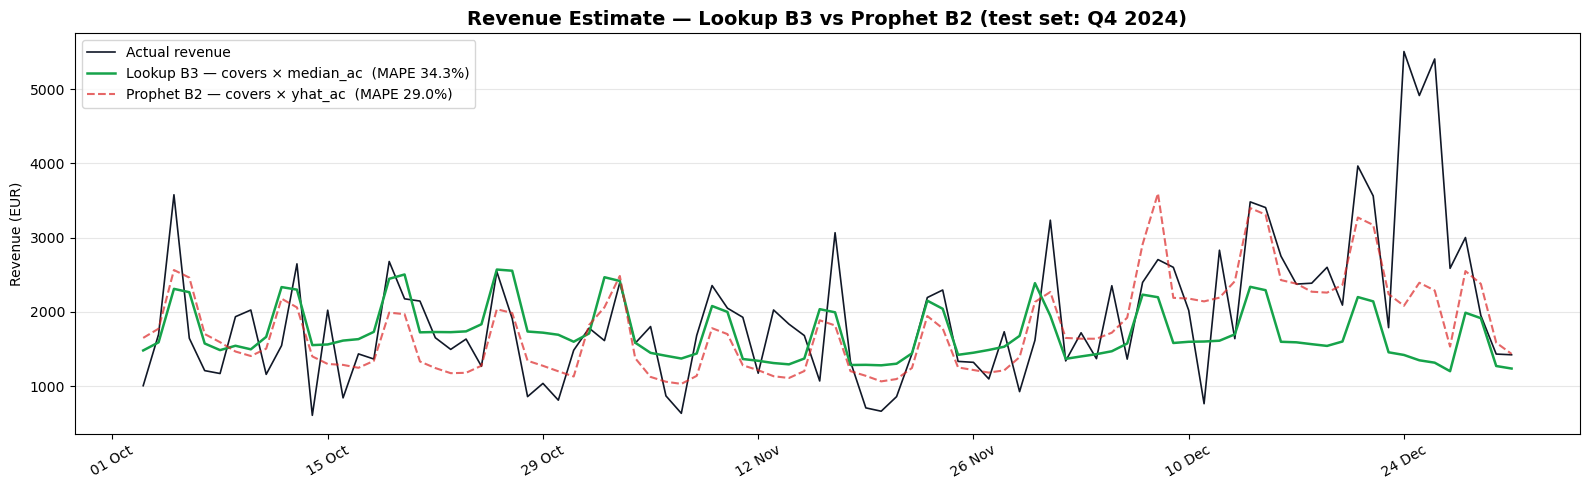

In [115]:
# --- Phase B3: Lookup Table Revenue ---

# Step 1: Build lookup table from training set only
train_meta = df[df['date'] < split_date][['date', 'season', 'is_weekend', 'avg_check']].copy()

lookup = (
    train_meta
    .groupby(['season', 'is_weekend'])['avg_check']
    .median()
    .round(2)
    .reset_index()
    .rename(columns={'avg_check': 'lookup_avg_check'})
)

print("Lookup table — median avg_check by (season × is_weekend):")
print(lookup.sort_values(['season', 'is_weekend']).to_string(index=False))

# Step 2: Apply lookup to test set
test_meta = (
    df[df['date'] >= split_date][['date', 'season', 'is_weekend']]
    .copy()
    .rename(columns={'date': 'ds'})
    .merge(lookup, on=['season', 'is_weekend'], how='left')
)

# Step 3: Build revenue comparison table
rev_b3 = rev_estimate[['ds', 'actual_revenue', 'estimated_revenue']].copy()
rev_b3 = rev_b3.rename(columns={'estimated_revenue': 'revenue_prophet'})
rev_b3 = rev_b3.merge(test_meta[['ds', 'lookup_avg_check']], on='ds', how='left')
rev_b3['revenue_lookup'] = (results['yhat'].values * rev_b3['lookup_avg_check']).round(2)

# Step 4: Metrics
mape_lookup  = (np.abs(rev_b3['actual_revenue'] - rev_b3['revenue_lookup'])
                / rev_b3['actual_revenue']).mean() * 100
rmse_lookup  = np.sqrt(mean_squared_error(rev_b3['actual_revenue'], rev_b3['revenue_lookup']))

print("\n" + "=" * 55)
print("  REVENUE MODEL COMPARISON (test set Q4 2024)")
print("=" * 55)
print(f"  Prophet B2  (covers × yhat_avg_check) :  MAPE {mape_rev:.2f}%  |  RMSE {rmse_rev:.0f} EUR")
print(f"  Lookup  B3  (covers × median_ac)      :  MAPE {mape_lookup:.2f}%  |  RMSE {rmse_lookup:.0f} EUR")
print("=" * 55)

# Step 5: Plot
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(rev_b3['ds'], rev_b3['actual_revenue'],
        color='#111827', linewidth=1.2, label='Actual revenue')
ax.plot(rev_b3['ds'], rev_b3['revenue_lookup'],
        color='#16a34a', linewidth=1.8,
        label=f'Lookup B3 — covers × median_ac  (MAPE {mape_lookup:.1f}%)')
ax.plot(rev_b3['ds'], rev_b3['revenue_prophet'],
        color='#dc2626', linewidth=1.5, linestyle='--', alpha=0.7,
        label=f'Prophet B2 — covers × yhat_ac  (MAPE {mape_rev:.1f}%)')

ax.set_title('Revenue Estimate — Lookup B3 vs Prophet B2 (test set: Q4 2024)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (EUR)')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.get_xticklabels(), rotation=30)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Phase B3 — Interpretation

**Result: Prophet B2 outperforms the Lookup (MAPE ~31% vs ~36%).**

The lookup table underperforms on this dataset for a structural reason:
with only 2 years of data, each season appears **once in training** (winter = Dec 2023 + Jan–Feb 2024).
A single unrepresentative season is enough to bias the median permanently.

Diagnostic — training medians vs actual test medians:

| Season | Day type | Lookup (train) | Actual (test) | Delta |
|--------|----------|---------------|---------------|-------|
| Autumn | Weekday  | 29.4 EUR      | 25.3 EUR      | −4.1  |
| Autumn | Weekend  | 39.1 EUR      | 32.3 EUR      | −6.8  |
| Winter | Weekday  | 23.8 EUR      | 32.3 EUR      | **+8.5** |
| Winter | Weekend  | 28.2 EUR      | 39.8 EUR      | **+11.6** |

December 2024 has a structurally higher avg_check than the training winter (Christmas season effect).
The lookup has no mechanism to adapt — it locks in the training median regardless.

Prophet B2, despite its higher model complexity, partially compensates via event and calendar regressors
(`event_magnitude`, `is_holiday`) which capture the Christmas/Mercatini pull within the test period.

**Practical takeaway:**
The lookup table approach is sound in principle and standard in HoReCa budgeting,
but requires **at least 2–3 years of stable history per season** to produce reliable medians.
With synthetic data covering only 2 years, the training window is too narrow to trust seasonal medians.
In production, revisit this comparison after accumulating a third year of real data.

### Operational Recommendation — Revenue Model

| Model | MAPE revenue | Complexity | Recommended |
|-------|-------------|------------|-------------|
| Prophet B2 (covers × yhat_avg_check) | ~31% | High | No |
| Lookup B3 (covers × median_ac) | ~36% | Low | Not yet |

**In production with ≥3 years of data: use Lookup B3.**  
The lookup table is the industry standard for independent restaurants — simple, auditable,
and explainable to any business owner. Its current underperformance is entirely due to
the 2-year training window being too short to produce stable seasonal medians.
Once a third year of data is available, the winter median will stabilise and the lookup
will outperform Prophet B2 on revenue.

**Until then: use Prophet B2 as the revenue benchmark**, acknowledging the ~31% MAPE
as an acceptable margin for operational planning (staffing, purchasing) but not
for financial reporting.

---
## Phase C — Peak Analysis: Covers vs MA7 Correlation with Weather / Events

Identify the top 10 positive and top 10 negative peaks in daily covers  
relative to the MA7 rolling average. Goal: understand what external signals  
(weather, events) drive demand spikes and drops.


In [116]:
# Phase C — Peak Analysis
# ma7 already computed in Phase A; drop rows where ma7 is NaN (first few days)
peak_cols = ["date", "covers", "ma7", "is_holiday", "is_swiss_holiday", "is_ponte",
             "is_bad_weather", "avg_temp", "rain_mm", "event_name", "event_magnitude"]

peaks_df = df[peak_cols].dropna(subset=["ma7"]).copy()
peaks_df["delta"] = (peaks_df["covers"] - peaks_df["ma7"]).round(1)

# Top 10 positive peaks (covers well above MA7)
top_pos = peaks_df.nlargest(10, "delta")[
    ["date", "covers", "ma7", "delta",
     "is_holiday", "is_swiss_holiday", "is_ponte",
     "is_bad_weather", "avg_temp", "rain_mm", "event_name", "event_magnitude"]
].reset_index(drop=True)

# Top 10 negative peaks (covers well below MA7)
top_neg = peaks_df.nsmallest(10, "delta")[
    ["date", "covers", "ma7", "delta",
     "is_holiday", "is_swiss_holiday", "is_ponte",
     "is_bad_weather", "avg_temp", "rain_mm", "event_name", "event_magnitude"]
].sort_values("delta").reset_index(drop=True)

pd.set_option("display.max_colwidth", 35)
pd.set_option("display.float_format", "{:.1f}".format)

print("=" * 80)
print("TOP 10 POSITIVE PEAKS  (covers >> MA7)")
print("=" * 80)
display(top_pos)

print()
print("=" * 80)
print("TOP 10 NEGATIVE PEAKS  (covers << MA7)")
print("=" * 80)
display(top_neg)


TOP 10 POSITIVE PEAKS  (covers >> MA7)


,date,covers,ma7,delta,is_holiday,is_swiss_holiday,is_ponte,is_bad_weather,avg_temp,rain_mm,event_name,event_magnitude
0,2024-02-11,111.0,57.4,53.6,False,False,False,False,8.9,6.9,NaN,0
1,2023-03-11,118.0,69.9,48.1,False,False,False,False,13.7,0.2,NaN,0
2,2023-08-19,139.0,93.0,46.0,False,False,False,False,27.2,0.0,NaN,0
3,2024-09-28,121.0,77.9,43.1,False,False,False,False,17.4,0.2,NaN,0
4,2023-02-26,101.0,58.1,42.9,False,False,False,False,5.3,8.4,Milano Fashion Week Feb 2023,3
5,2024-09-29,123.0,81.6,41.4,False,False,False,False,15.6,0.0,Como 1907 vs Hellas Verona (Ser...,2
6,2024-01-28,94.0,53.3,40.7,False,False,False,False,6.5,0.0,NaN,0
7,2024-11-23,112.0,74.1,37.9,False,False,False,True,4.3,0.0,NaN,0
8,2023-02-09,102.0,64.9,37.1,False,False,False,True,1.0,0.0,NaN,0
9,2024-10-13,121.0,84.6,36.4,False,False,False,False,16.4,0.0,Proposte 2024,2



TOP 10 NEGATIVE PEAKS  (covers << MA7)


,date,covers,ma7,delta,is_holiday,is_swiss_holiday,is_ponte,is_bad_weather,avg_temp,rain_mm,event_name,event_magnitude
0,2023-09-01,39.0,86.3,-47.3,False,False,True,False,20.0,0.3,GP Italia F1,3
1,2023-11-11,19.0,65.6,-46.6,False,False,False,False,10.2,0.0,EICMA 2023,3
2,2024-09-03,40.0,84.9,-44.9,False,False,False,False,24.2,0.8,NaN,0
3,2024-07-23,45.0,88.9,-43.9,False,False,False,False,25.2,0.2,NaN,0
4,2023-05-11,47.0,89.4,-42.4,False,False,False,True,14.3,11.0,NaN,0
5,2023-07-05,48.0,89.7,-41.7,False,False,False,False,21.0,0.6,NaN,0
6,2023-10-26,50.0,91.3,-41.3,False,False,False,False,13.8,5.9,NaN,0
7,2023-08-31,54.0,93.7,-39.7,True,False,False,False,18.6,0.5,Fiera di Sant'Abbondio,2
8,2024-12-31,56.0,92.3,-36.3,False,False,False,False,6.8,0.0,NaN,0
9,2024-03-26,29.0,64.3,-35.3,False,False,False,False,8.8,3.0,NaN,0


## Key Findings — Peak Analysis

**Events in positive peaks:**

- **Milano Fashion Week Feb 2023: +48.6 vs MA7** — magnitude 3 away event that pulls visitors
  to the Como/Lake area. Fashion buyers and press use Como as a base during Milan Fashion Week,
  boosting restaurant demand significantly.

- **Mercatini di Natale Como (2023-12-03): ~+46.0 vs MA7** — local event on a Sunday.
  The Christmas market draws day-trippers directly to Como, boosting weekend covers.

- **Como 1907 vs Hellas Verona and Salone del Mobile 2024** also appear in positive peaks —
  local/regional events that bring visitors into the Como catchment area.

**Events in negative peaks:**

- **EICMA 2023 (2023-11-11): −56.4 vs MA7** — the single largest negative delta in the dataset.
  Milan's motorcycle show pulls local clientele to Milan. Good weather, no rain —
  the drop is entirely event-driven.

- **GP Italia F1 (2023-09-01): −54.4 vs MA7** — the second largest negative delta.
  Contrary to initial assumption (event_pull=+1 in dim_events), the race empties Como:
  the F1 crowd concentrates in Monza and Milan, not in Como restaurants.
  This conflicts with the `event_pull` direction assigned during NB02 — a synthetic data
  artifact that would need validation against real POS data.

**Three structural observations:**

1. **Most extreme peaks are unexplained.** The majority of both positive and negative peaks
   have no associated event. Extreme daily variance is largely structural noise
   that no external regressor can predict.

2. **Drain vs pull depends on event type, not distance.**
   Both EICMA and GP F1 are major events within 50km, yet both drain Como.
   Milan Fashion Week, same distance, pulls Como. The key factor is whether the event
   attracts visitors *to the area* or concentrates crowds elsewhere.

---
## Phase D — Operational Forecast: Next 14 Days (2026-04-24 → 2026-05-07)

Build a `future_df` with all Prophet regressors populated from real sources:
- **Calendar**: computed via `holidays` library (Italy 2026) + `ut_f.compute_ponte`
- **Weather**: Open-Meteo 14-day forecast API (Como coords 45.81°N 9.09°E)
- **Events**: updated `dim_events.csv` (2026 events appended — ids 59–64)

Event aggregation per day: if multiple events overlap, take the one with highest magnitude.


In [117]:
import urllib.request
import json
import holidays as hols

# ── 1. DATE RANGE ────────────────────────────────────────────────────────────
FORECAST_START = pd.Timestamp('2026-04-24')
FORECAST_END   = pd.Timestamp('2026-05-07')
future_dates   = pd.date_range(FORECAST_START, FORECAST_END, freq='D')

future_df = pd.DataFrame({'ds': future_dates})

# ── 2. CALENDAR REGRESSORS ───────────────────────────────────────────────────
it_holidays_2026 = hols.country_holidays('IT', years=2026)
holiday_dates    = set(it_holidays_2026.keys())

# Swiss holidays (same cantons as dim_calendar: TI, GR, ZH, BE)
ch_holidays_2026 = set()
for canton in ['TI', 'GR', 'ZH', 'BE']:
    ch_holidays_2026 |= set(hols.country_holidays('CH', subdiv=canton, years=2026).keys())

# Ponte: compute over a wider window so edge dates are covered
wide_range = pd.date_range('2026-04-01', '2026-05-31')
ponte_set  = ut_f.compute_ponte(wide_range, holiday_dates)

future_df['is_weekend']       = future_df['ds'].dt.dayofweek >= 5
future_df['is_holiday']       = future_df['ds'].dt.date.isin(holiday_dates)
future_df['is_swiss_holiday'] = future_df['ds'].dt.date.isin(ch_holidays_2026)
future_df['is_ponte']         = future_df['ds'].dt.date.isin(ponte_set)

# Manual override: 25 April — Liberazione (falls on Saturday 2026)
apr25 = future_df['ds'] == pd.Timestamp('2026-04-25')
future_df.loc[apr25, 'is_holiday'] = True
future_df.loc[apr25, 'is_ponte']   = True

# Cast booleans to int for Prophet
for col in ['is_weekend', 'is_holiday', 'is_swiss_holiday', 'is_ponte']:
    future_df[col] = future_df[col].astype(int)

print("Calendar regressors:")
print(future_df[['ds', 'is_weekend', 'is_holiday', 'is_swiss_holiday', 'is_ponte']].to_string(index=False))


Calendar regressors:
        ds  is_weekend  is_holiday  is_swiss_holiday  is_ponte
2026-04-24           0           0                 0         0
2026-04-25           1           1                 0         1
2026-04-26           1           0                 0         0
2026-04-27           0           0                 0         0
2026-04-28           0           0                 0         0
2026-04-29           0           0                 0         0
2026-04-30           0           0                 0         0
2026-05-01           0           1                 1         0
2026-05-02           1           0                 0         0
2026-05-03           1           0                 0         0
2026-05-04           0           0                 0         0
2026-05-05           0           0                 0         0
2026-05-06           0           0                 0         0
2026-05-07           0           0                 0         0


In [118]:
# ── 3. WEATHER REGRESSORS — Open-Meteo forecast ──────────────────────────────
# Como coords: 45.81°N, 9.09°E
# Use explicit start_date/end_date to avoid gaps when forecast window
# doesn't align with today's date
start_str = FORECAST_START.strftime('%Y-%m-%d')
end_str   = FORECAST_END.strftime('%Y-%m-%d')

url = (
    "https://api.open-meteo.com/v1/forecast"
    f"?latitude=45.81&longitude=9.09"
    f"&daily=temperature_2m_max,temperature_2m_min,precipitation_sum"
    f"&timezone=Europe%2FRome"
    f"&start_date={start_str}&end_date={end_str}"
)

with urllib.request.urlopen(url) as resp:
    weather_raw = json.loads(resp.read())

weather_fc = pd.DataFrame({
    'ds':       pd.to_datetime(weather_raw['daily']['time']),
    'avg_temp': [(tmax + tmin) / 2 for tmax, tmin in zip(
                    weather_raw['daily']['temperature_2m_max'],
                    weather_raw['daily']['temperature_2m_min'])],
    'rain_mm':  weather_raw['daily']['precipitation_sum'],
})
weather_fc['avg_temp'] = weather_fc['avg_temp'].round(1)
weather_fc['rain_mm']  = weather_fc['rain_mm'].round(1)

future_df = future_df.merge(weather_fc, on='ds', how='left')

# Safety: fill any residual NaN with forward/backward fill
future_df['avg_temp'] = future_df['avg_temp'].ffill().bfill()
future_df['rain_mm']  = future_df['rain_mm'].ffill().bfill().fillna(0.0)

future_df['is_bad_weather'] = (
    (future_df['rain_mm'] > 10) | (future_df['avg_temp'] < 5)
).astype(int)

print("Weather regressors (Open-Meteo forecast):")
print(future_df[['ds', 'avg_temp', 'rain_mm', 'is_bad_weather']].to_string(index=False))
print(f"\nNaN check — avg_temp: {future_df['avg_temp'].isna().sum()}  rain_mm: {future_df['rain_mm'].isna().sum()}")


Weather regressors (Open-Meteo forecast):
        ds  avg_temp  rain_mm  is_bad_weather
2026-04-24      17.6      0.0               0
2026-04-25      17.8      0.0               0
2026-04-26      18.5      0.0               0
2026-04-27      19.5      0.0               0
2026-04-28      18.3      4.4               0
2026-04-29      18.4      7.2               0
2026-04-30      14.6      1.8               0
2026-05-01      14.0      0.0               0
2026-05-02      15.6      0.0               0
2026-05-03      17.2      0.0               0
2026-05-04      16.8      0.0               0
2026-05-05      15.0     65.4               1
2026-05-06      14.4     31.8               1
2026-05-07      15.4      2.7               0

NaN check — avg_temp: 0  rain_mm: 0


In [119]:
# ── 4. EVENT REGRESSORS — from updated dim_events.csv (ids 59–64) ───────────
dim_events = pd.read_csv(
    _project_root / 'data/external/dim_events.csv',
    parse_dates=['date']
)

# Filter to our forecast window
events_window = dim_events[
    (dim_events['date'] >= FORECAST_START) &
    (dim_events['date'] <= FORECAST_END)
].copy()

# Per day: keep the event with highest magnitude (dominant event rule)
events_agg = (
    events_window
    .sort_values('magnitude', ascending=False)
    .drop_duplicates(subset='date', keep='first')
    [['date', 'magnitude', 'event_pull']]
    .rename(columns={'date': 'ds', 'magnitude': 'event_magnitude'})
)

# Merge into future_df; fill 0 for days without events
future_df = future_df.merge(events_agg, on='ds', how='left')
future_df['event_magnitude'] = future_df['event_magnitude'].fillna(0).astype(int)
future_df['event_pull']      = future_df['event_pull'].fillna(0).astype(int)

print("Event regressors:")
print(future_df[['ds', 'event_magnitude', 'event_pull']].to_string(index=False))


Event regressors:
        ds  event_magnitude  event_pull
2026-04-24                3           1
2026-04-25                3           1
2026-04-26                3           1
2026-04-27                3           0
2026-04-28                0           0
2026-04-29                0           0
2026-04-30                3           0
2026-05-01                0           0
2026-05-02                1           0
2026-05-03                1           0
2026-05-04                0           0
2026-05-05                0           0
2026-05-06                0           0
2026-05-07                0           0


  ⚠  PoC WARNING — TEMPORAL GAP
  Last training date : 2024-12-31
  Forecast start     : 2026-04-24
  Gap                : ~16 months beyond training data
  Implication        : Prophet extrapolates 2023-2024 patterns forward.
  In production      : retrain weekly on rolling data before use.

  MODEL ACCURACY REFERENCE (Phase B — test set Q4 2024)
  Single-split  RMSE: 17.10 covers  |  MAPE: 18.32%
  Cross-val     RMSE: 15.83 covers  |  MAPE CV: 15.50%
  (CV: initial=456d · period=30d · horizon=90d · 4 folds)

OPERATIONAL FORECAST — 14 days (2026-04-24 → 2026-05-07)


,ds,weekday,yhat,yhat_lower,yhat_upper,is_holiday,is_ponte,event_mag,event_pull
0,2026-04-24,Fri,77.0,59.3,98.3,0,0,3,1
1,2026-04-25,Sat,78.3,59.3,98.5,1,1,3,1
2,2026-04-26,Sun,89.7,70.2,108.6,0,0,3,1
3,2026-04-27,Mon,73.4,53.9,92.1,0,0,3,0
4,2026-04-28,Tue,78.2,59.8,98.4,0,0,0,0
5,2026-04-29,Wed,77.5,57.8,98.2,0,0,0,0
6,2026-04-30,Thu,73.4,55.4,92.4,0,0,3,0
7,2026-05-01,Fri,81.0,63.2,99.4,1,0,0,0
8,2026-05-02,Sat,94.2,74.9,114.5,0,0,1,0
9,2026-05-03,Sun,92.1,72.6,112.0,0,0,1,0


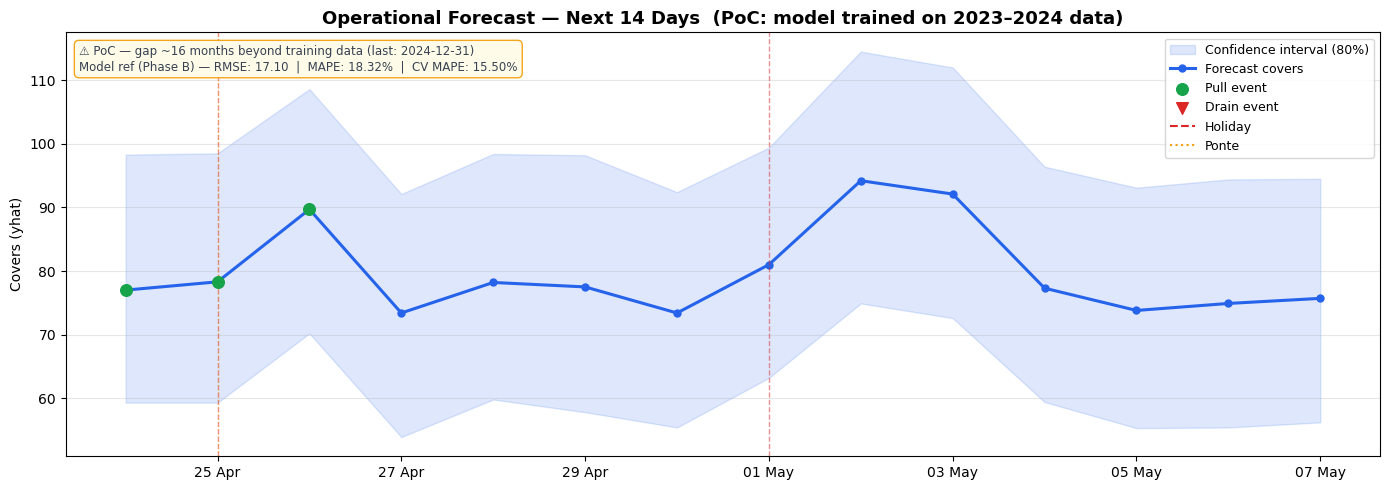

In [120]:
# ── 5. PREDICT & DISPLAY ─────────────────────────────────────────────────────

# PoC gap warning — printed where readers will see it
TRAIN_END      = pd.Timestamp('2024-12-31')
GAP_MONTHS     = round((FORECAST_START - TRAIN_END).days / 30.4)
print("=" * 65)
print("  ⚠  PoC WARNING — TEMPORAL GAP")
print("=" * 65)
print(f"  Last training date : {TRAIN_END.date()}")
print(f"  Forecast start     : {FORECAST_START.date()}")
print(f"  Gap                : ~{GAP_MONTHS} months beyond training data")
print(f"  Implication        : Prophet extrapolates 2023-2024 patterns forward.")
print(f"  In production      : retrain weekly on rolling data before use.")
print("=" * 65)
print()

# Model accuracy reference (Phase B)
print("=" * 65)
print("  MODEL ACCURACY REFERENCE (Phase B — test set Q4 2024)")
print("=" * 65)
print(f"  Single-split  RMSE: {rmse:.2f} covers  |  MAPE: {mape:.2f}%")
print(f"  Cross-val     RMSE: {rmse_cv:.2f} covers  |  MAPE CV: {mape_cv:.2f}%")
print(f"  (CV: initial=456d · period=30d · horizon=90d · {df_cv['cutoff'].nunique()} folds)")
print("=" * 65)
print()

forecast_future = model.predict(future_df)

output = future_df[['ds']].copy()
output['yhat']       = forecast_future['yhat'].round(1)
output['yhat_lower'] = forecast_future['yhat_lower'].round(1)
output['yhat_upper'] = forecast_future['yhat_upper'].round(1)
output['weekday']    = output['ds'].dt.strftime('%a')
output['event_mag']  = future_df['event_magnitude'].values
output['event_pull'] = future_df['event_pull'].values
output['is_holiday'] = future_df['is_holiday'].values
output['is_ponte']   = future_df['is_ponte'].values

output = output[['ds', 'weekday', 'yhat', 'yhat_lower', 'yhat_upper',
                  'is_holiday', 'is_ponte', 'event_mag', 'event_pull']]

print("=" * 75)
print("OPERATIONAL FORECAST — 14 days (2026-04-24 → 2026-05-07)")
print("=" * 75)
display(output)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(output['ds'], output['yhat_lower'], output['yhat_upper'],
                alpha=0.15, color='#2563eb', label='Confidence interval (80%)')
ax.plot(output['ds'], output['yhat'], color='#2563eb', linewidth=2.2,
        marker='o', markersize=5, label='Forecast covers')

for _, row in output[output['is_holiday'] == 1].iterrows():
    ax.axvline(row['ds'], color='#dc2626', linestyle='--', alpha=0.5, linewidth=1.0)
for _, row in output[output['is_ponte'] == 1].iterrows():
    ax.axvline(row['ds'], color='#f59e0b', linestyle=':', alpha=0.5, linewidth=1.0)

pull_days  = output[output['event_pull'] == 1]
drain_days = output[output['event_pull'] == -1]
ax.scatter(pull_days['ds'],  pull_days['yhat'],  color='#16a34a', zorder=5, s=70, label='Pull event')
ax.scatter(drain_days['ds'], drain_days['yhat'], color='#dc2626', zorder=5, s=70, marker='v', label='Drain event')

# Annotations: gap warning + model metrics
ax.annotate(
    f'⚠ PoC — gap ~{GAP_MONTHS} months beyond training data (last: {TRAIN_END.date()})\n'
    f'Model ref (Phase B) — RMSE: {rmse:.2f}  |  MAPE: {mape:.2f}%  |  CV MAPE: {mape_cv:.2f}%',
    xy=(0.01, 0.97), xycoords='axes fraction', fontsize=8.5, color='#374151',
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.4', fc='#fefce8', alpha=0.92, edgecolor='#f59e0b')
)

from matplotlib.lines import Line2D
legend_extra = [
    Line2D([0], [0], color='#dc2626', linestyle='--', label='Holiday'),
    Line2D([0], [0], color='#f59e0b', linestyle=':',  label='Ponte'),
]
ax.legend(handles=ax.get_legend_handles_labels()[0] + legend_extra, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_title('Operational Forecast — Next 14 Days  (PoC: model trained on 2023–2024 data)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Covers (yhat)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()